In [1]:
%reload_ext tensorboard

In [ ]:
#rm -rf ./logs/

In [2]:
%tensorboard --logdir logs/gradient_tape

In [3]:
import tensorflow as tf

In [4]:
path = '/Users/erinbjorkeli/Documents/GitHub/deep-spectra/AE_cls_Sept_2022-09-06 09%3A47%3A56.610455'
model = tf.keras.models.load_model(path)

Metal device set to: Apple M1


2022-09-07 10:17:15.465537: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-09-07 10:17:15.466201: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1024, 2)]    0           []                               
                                                                                                  
 flatten (Flatten)              (None, 2048)         0           ['input_1[0][0]']                
                                                                                                  
 dense (Dense)                  (None, 2048)         4196352     ['flatten[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 2048)         0           ['dense[0][0]']                  
                                                                                       

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt

import seaborn as sns

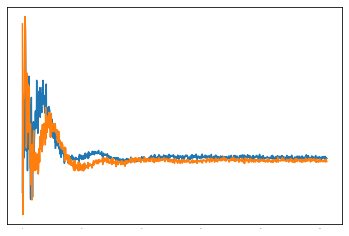

In [7]:
i = 330 #2370  # norm 14000  #gbm 330
path = '/Users/erinbjorkeli/phd/Data_Spectra /ReIm_data_3/gbm'
labtest = np.load(os.path.join(path, 'train/train_time_data.npy'), allow_pickle=True)[i] # nhx 100, 220
fig = plt.plot(labtest)

plt.tick_params(axis='both', labelsize=0, length = 0)
ax = plt.gca()

ax.get_yaxis().set_visible(False)

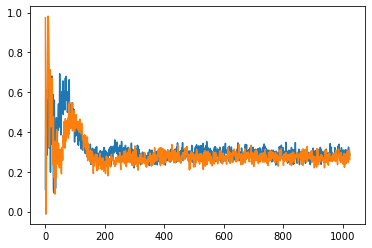

In [8]:
lab2 = labtest + np.random.normal(0, 2e-2, labtest.shape)
plt.plot(lab2)

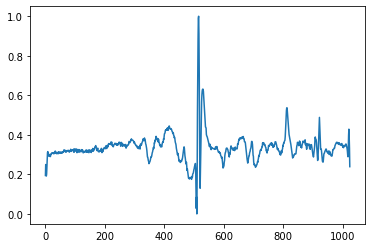

In [9]:
labtest2 = np.load(os.path.join(path, 'train/train_freq_data.npy'), allow_pickle=True)[i]
plt.plot(labtest2[:])

In [10]:
from Utils.Domain_transform import fft_spectra

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


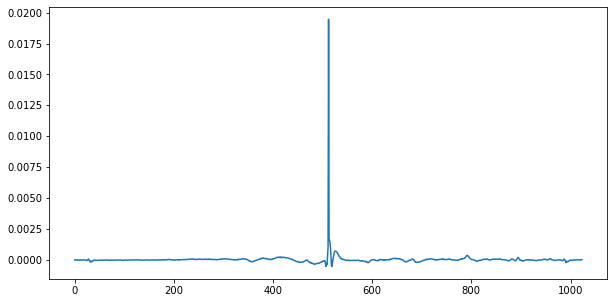

In [11]:
ii = fft_spectra(labtest[np.newaxis])

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


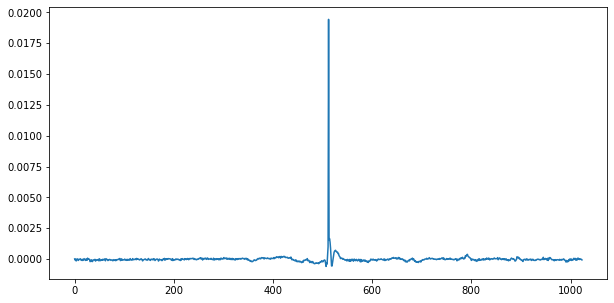

In [12]:
ii = fft_spectra(lab2[np.newaxis])

In [13]:
labtest.shape

(1024, 2)

In [19]:
test = None
np.concatenate((test,labtest)).shape

ValueError: zero-dimensional arrays cannot be concatenated

In [14]:
_, _, _, x1, _ = model.predict(labtest[np.newaxis])

2022-09-07 10:17:35.930965: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-09-07 10:17:36.016517: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 371ms/step


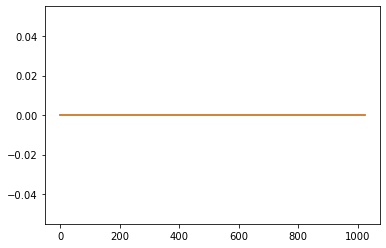

In [15]:
plt.plot(x1[0])

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


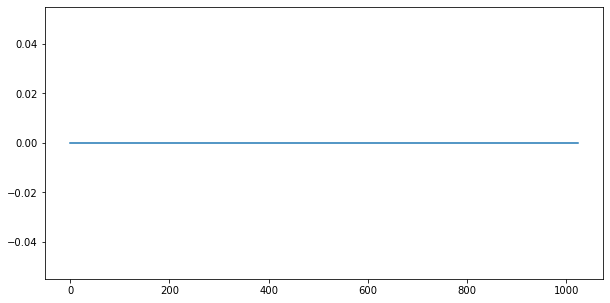

In [16]:
jj = fft_spectra(x1)

In [26]:
cf = 128#*2 #* 1e6
dwelltime = 400#833
bandwidth = 1 / dwelltime
points = 1024
x = np.linspace(-bandwidth / 2, bandwidth / 2, points)
xs = hz2ppm(cf, x, shift=True, shift_amount=4.65)

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


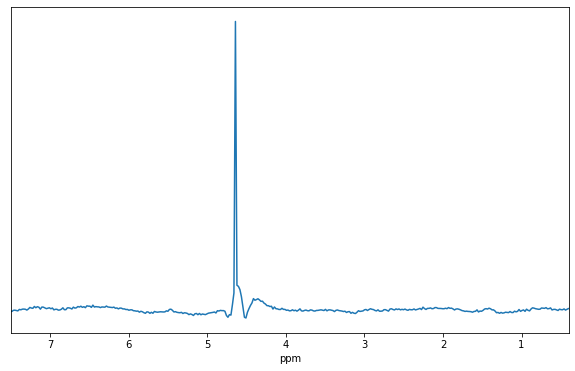

In [27]:
fig = plt.figure(figsize=(10,6))
plt.plot(np.flip(xs), ii)
plt.yticks([])
plt.xlim([0.4, 7.5])
plt.xlabel('ppm')
plt.gca().invert_xaxis()
#plt.plot(jj)

/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


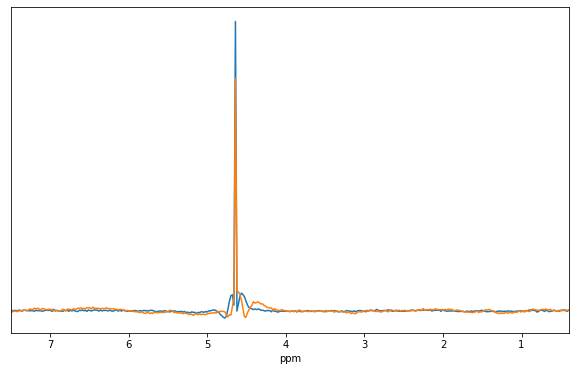

In [29]:
fig = plt.figure(figsize=(10,6))
plt.plot(np.flip(xs), jj)
plt.yticks([])
plt.xlim([0.4, 7.5])
plt.xlabel('ppm')
plt.gca().invert_xaxis()
plt.plot(np.flip(xs), ii)

In [118]:
matplotlib.rcParams.update({'font.size': 10})


NameError: name 'matplotlib' is not defined

In [17]:
from Utils.evaluation import evaluate
from os.path import join

In [18]:
config = {'data_path' : "/Users/erinbjorkeli/phd/Data_Spectra /ReIm_data_3"}
N2 = None

# External validation (new set)
test_time = np.load(join(config['data_path'], 'test/test_time_data.npy'), allow_pickle=True)[:N2]
test_labels = np.load(join(config['data_path'], 'test/test_labels.npy'), allow_pickle=True)[:N2]

print('External data:')
pred = model.predict(test_time)
evaluate(pred, test_labels, plot_cm=True, name='CM_test_nhx')

test_time = np.load(join(config['data_path'], 'test_gbm/test_time_data.npy'), allow_pickle=True)
# test_time = np.load(join(config))
result = (model.predict(test_time)[0] > 0.5) * 1
print('EXT  Just glioma accuracy:', np.sum(result) / len(result))

test_time = np.load(join(config['data_path'], 'test_healthy/test_time_data.npy'), allow_pickle=True)
result = (model.predict(test_time)[0] > 0.5) * 1
print('EXT  Just healthy accuracy:', np.sum(result) / len(result))

External data:
2048/2048 [==============================] - 20s 9ms/step
Accuracy: 0.314605712890625
Predicted GBM 31.4605712890625% 
 Actual GBM 100.0 %
False negative rate: 0.685394287109375


/Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:990: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


237/237 [==============================] - 2s 10ms/step
EXT  Just glioma accuracy: 0.3237704918032787
1812/1812 [==============================] - 17s 10ms/step
EXT  Just healthy accuracy: 0.31340992203132545


In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
aa = np.load('test_reconstruction_dense_10eps_1e3.npy')
bb = np.load('input_reconstruction_dense_1e3.npy')
plt.plot(aa[0,:,1])
plt.plot(bb[0,:,1])

In [ ]:
aa.shape

In [ ]:
fft_spectra(aa)

In [ ]:
from Utils.spectra_error_plotting import Visualise

In [ ]:
a, b = fft_spectra(aa, plot=False), fft_spectra(bb, plot=False)

In [25]:
def hz2ppm(cf, hz, shift=True, shift_amount=0):
    """Convert frequency scale to frequency scale with optional shift."""
    if shift:
        return 1e6 * hz / cf + shift_amount
    else:
        return 1e6 * hz / cf

In [ ]:
cf = 128 #* 1e6
dwelltime = 833
bandwidth = 1 / dwelltime
points = 1024
x = np.linspace(-bandwidth / 2, bandwidth / 2, points)
xs = hz2ppm(cf, x, shift=True, shift_amount=4.65)

In [ ]:
fig = plt.figure(figsize=(10,6))
plt.plot(xs, a)#[550:800])
plt.plot(xs, b)#[550:800])
plt.yticks([])
plt.xlim([0.4, 4.2])
plt.xlabel('ppm')
plt.gca().invert_xaxis()

In [ ]:
x = np.arange(10)
x

In [ ]:
np.random.shuffle(x)
x

In [ ]:
vis = Visualise(b, a, 0)

In [ ]:
vis.error(N=4)

In [308]:
# 109 for example
tn = 11169
fp = 79
tp = 8683
fn = 7740

cm = [[tn, fp], [tp,fn]]

labels = ['healthy', 'gbm']

In [310]:
(tp + tn) / (tp+tn+fp+fn)

0.7174298001517835

In [ ]:
c1 = [5953,0,1166,0]
c2 = [524,0,571,0]
c3 = [5676,0,4477,0]
c4 = [1951,0,7353,0]

cm = [c1,c2,c3,c4]

labels = ['m1', 'm2', 'm3', 'm4']

In [ ]:
c1 = [5928,0,0,0,0,1191]
c2 = [2704,0,0,0,0,6600]
c3 = [151,0,0,0,0,215]
c4 = [173,0,0,0,0,196]
c5 = [177,0,0,0,0,183]
c6 = [6394,0,0,0,0,3759]

cm = [c1,c2,c3,c4,c5,c6]

labels = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt   
import matplotlib
from matplotlib.colors import LogNorm, Normalize


matplotlib.rcParams.update({'font.size': 22})

fig = plt.subplots(1,1,figsize=(12,10))
ax = plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap=sns.color_palette("PuBu", as_cmap=True))#, norm=LogNorm());  #annot=True to annotate cells, ftm='g' to disable scientific notation


# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels);


In [ ]:
# create cms

# example of recreated spectra...